In [2]:
import pandas as pd
import numpy as np
import requests

# 1. Fetch daily agroclimatic data from NASA POWER API (2023-2025)
url = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,RH2M,PRECTOTCORR&community=AG&longitude=88.64&latitude=25.62&start=20230101&end=20251231&format=JSON"

response = requests.get(url)
data = response.json()

# Process JSON response into DataFrame
properties = data['properties']['parameter']
df = pd.DataFrame(properties)
df.reset_index(inplace=True)
df.rename(columns={
    'index': 'YYYYMMDD',
    'T2M': 'temperature',
    'RH2M': 'humidity',
    'PRECTOTCORR': 'rainfall'
}, inplace=True)

# 2. Generate soil attributes based on regional SRDI guidelines
np.random.seed(42)
n_rows = len(df)

df['N'] = np.random.uniform(15, 35, n_rows).round(1)
df['P'] = np.random.uniform(12, 28, n_rows).round(1)
df['K'] = np.random.uniform(25, 50, n_rows).round(1)
df['ph'] = np.random.uniform(5.5, 6.8, n_rows).round(2)

# 3. Export clean dataset
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df_final = df[features]
df_final.to_csv('dinajpur_crop_selection_dataset.csv', index=False)
print("Dataset created successfully: 'dinajpur_crop_selection_dataset.csv'")

Dataset created successfully: 'dinajpur_crop_selection_dataset.csv'


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load dataset
df = pd.read_csv('dinajpur_crop_selection_dataset.csv')

# 2. Rule-based crop label mapping for Dinajpur region
def assign_crop(row):
    temp = row['temperature']
    rain = row['rainfall']
    ph = row['ph']

    if rain > 10 and temp > 22:
        return 'rice'
    elif temp < 20 and rain < 5:
        return 'wheat'
    elif 18 <= temp <= 28 and rain < 8:
        return 'maize'
    elif temp < 18:
        return 'potato'
    elif temp >= 25 and ph >= 6.0:
        return 'litchi'
    else:
        return 'jute'

df['label'] = df.apply(assign_crop, axis=1)

# 3. Features and Target split
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Training Complete!")
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Training Complete!
Model Accuracy: 99.09%

Classification Report:
               precision    recall  f1-score   support

        jute       1.00      0.91      0.95        23
      litchi       1.00      1.00      1.00        36
       maize       1.00      1.00      1.00        69
        rice       0.96      1.00      0.98        46
       wheat       1.00      1.00      1.00        46

    accuracy                           0.99       220
   macro avg       0.99      0.98      0.99       220
weighted avg       0.99      0.99      0.99       220



In [4]:
# Sample input values: [N, P, K, temperature, humidity, ph, rainfall]
sample_data = [[25.0, 18.0, 35.0, 16.5, 65.0, 6.2, 2.0]]

predicted_crop = model.predict(sample_data)
print(f"Predicted Crop for given conditions: {predicted_crop[0].upper()}")

Predicted Crop for given conditions: WHEAT


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


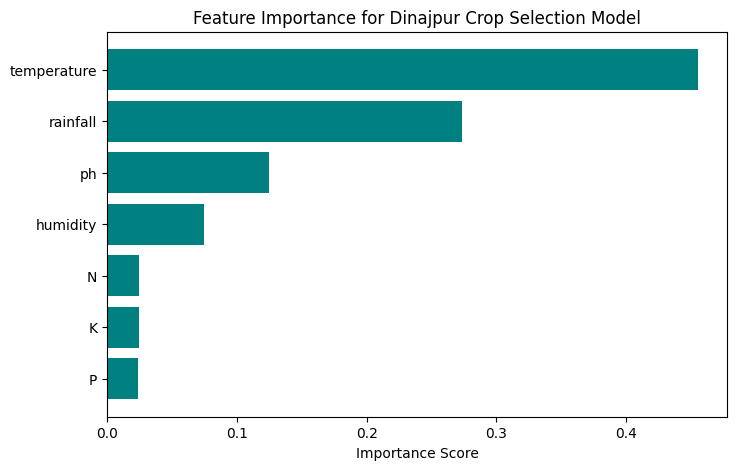

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the trained model
importances = model.feature_importances_
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Create a DataFrame for visualization
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(8, 5))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Dinajpur Crop Selection Model')
plt.show()